In [48]:
!pip install unidecode spacy nltk
!python -m spacy download fr_core_news_sm

Traceback (most recent call last):
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 148, in _get_module_details
  File "<frozen runpy>", line 112, in _get_module_details
  File "/usr/local/lib/python3.11/dist-packages/spacy/__init__.py", line 16, in <module>
    from .cli.info import info  # noqa: F401
    ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/spacy/cli/__init__.py", line 4, in <module>
    from . import download as download_module  # noqa: F401
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/spacy/cli/download.py", line 5, in <module>
    import requests
  File "/usr/local/lib/python3.11/dist-packages/requests/__init__.py", line 164, in <module>
    from .api import delete, get, head, options, patch, post, put, request
  File "/usr/local/lib/python3.11/dist-packages/requests/api.py", line 11, in <module>
    from . import sessions
  File "/usr/local/lib/python3.11/

In [60]:
import pandas as pd
import numpy as np
import re
import unidecode
import nltk
import pickle
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Télécharger les stopwords si nécessaire
nltk.download('stopwords')
stop_words = set(stopwords.words('french'))


class Processing:
    def __init__(self, path):
        self.df = pd.read_csv(path)

    def inspect_data(self):
        print("Shape:", self.df.shape)
        print("Columns:", self.df.columns)
        print(self.df.info())
        print("First 5 rows:\n", self.df.head())
        print("Last 10 rows:\n", self.df.tail(10))

    def check_missing_values(self):
        na_cols = self.df.columns[self.df.isna().any()].tolist()
        print("Colonnes avec valeurs manquantes :", na_cols)
        print("Nombre de valeurs manquantes :\n", self.df.isna().sum())
        print("Pourcentage de valeurs manquantes :\n", self.df.isna().sum()/len(self.df)*100)
        return na_cols

    def remove_unused_columns(self):
        cols_to_drop = ["Cod_cmd","Vendeur", "Date de commande", " Montant cmd ", "Quantité", "Prix transport", "Délai transport annoncé"]
        self.df.drop(columns=[c for c in cols_to_drop if c in self.df.columns], inplace=True)

    def remove_rows_with_all_labels_missing(self):
        before = self.df.shape[0]
        self.df = self.df[~(self.df["Univers"].isna() & self.df["Nature"].isna())]
        after = self.df.shape[0]
        print(f"Suppression de {before - after} lignes avec Univers et Nature manquants (Correspont à des services).")

    def display_categories(self):
        print("Catégories Univers :", self.df["Univers"].unique())
        print("Nombre :", self.df["Univers"].nunique())
        print("Catégories Nature :", self.df["Nature"].unique())
        print("Nombre :", self.df["Nature"].nunique())

        group = self.df.groupby("Univers")["Nature"].unique()
        for u, n in group.items():
            print(f"Univers : {u}")
            for nat in n:
                print(f"   - {nat}")
            print("\n" + "-"*50 + "\n")

    def clean_labels(self):
        self.df.dropna(subset=["Libellé produit"], inplace=True)
        self.df.reset_index(drop=True, inplace=True)

    def get_data(self):
        return self.df

    def remove_duplicates(self):
        before = self.df.shape[0]
        self.df = self.df.drop_duplicates(subset="Libellé produit", keep="first").reset_index(drop=True)
        after = self.df.shape[0]
        print(f"Doublons supprimés : {before - after}")


class TextCleaner:
    def __init__(self, df, column='Libellé produit'):
        self.df = df.copy()
        self.column = column

    def clean_text(self, text):
        if pd.isnull(text):
            return ""
        text = text.lower()
        text = unidecode.unidecode(text)
        text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
        tokens = text.split()
        tokens = [t for t in tokens if t not in stop_words]
        return " ".join(tokens)

    def apply_cleaning(self):
        self.df["Libellé produit"] = self.df[self.column].apply(self.clean_text)

    def get_data(self):
        return self.df

class ProcessingModeler:
    def __init__(self, df):
        self.df = df.copy()
        self.vectorizer_univ = TfidfVectorizer(max_features=10000)
        self.le_univers = LabelEncoder()
        self.le_nature = LabelEncoder()
        self.clf_univers = LogisticRegression(max_iter=1000, class_weight="balanced")

    def predict_missing_univers(self):
        # Séparer les lignes complètes et incomplètes
        data_complete = self.df.dropna(subset=["Univers", "Nature"]).copy()
        data_missing_univ = self.df[self.df["Univers"].isna() & self.df["Nature"].notna()].copy()

        # Encoder pour apprentissage
        univers_code = self.le_univers.fit_transform(data_complete["Univers"])
        nature_code = self.le_nature.fit_transform(data_complete["Nature"])  # utilisé uniquement si besoin

        # Données texte
        X_text = data_complete["Libellé produit"]
        y_univers = univers_code

        # Vectorisation
        X_vect = self.vectorizer_univ.fit_transform(X_text)

        # Split
        X_train, X_val, y_train, y_val = train_test_split(X_vect, y_univers, stratify=y_univers, test_size=0.2, random_state=42)

        # Entraînement
        self.clf_univers.fit(X_train, y_train)

        # Évaluation
        y_pred = self.clf_univers.predict(X_val)
        print("Évaluation du modèle Univers :")
        print(classification_report(y_val, y_pred, target_names=self.le_univers.classes_))

        # Prédiction sur les lignes manquantes
        X_missing_univ = self.vectorizer_univ.transform(data_missing_univ["Libellé produit"])
        pred_univers_code = self.clf_univers.predict(X_missing_univ)
        pred_univers = self.le_univers.inverse_transform(pred_univers_code)

        # Ajout de la prédiction dans une copie du DataFrame incomplet
        data_missing_univ = data_missing_univ.copy()
        data_missing_univ["Univers"] = pred_univers

        # Fusion
        data_final = pd.concat([data_complete, data_missing_univ], ignore_index=True)

        print("Dataset final :", data_final.shape)
        print("Univers manquants restants :", data_final["Univers"].isna().sum())

        return data_final

class FeatureExtractor:
    def __init__(self, df):
        self.df = df.copy()

        # Dictionnaire de couleurs et variantes
        self.color_map = {
            "noir": ["noir", "ébène"],
            "blanc": ["blanc", "ivoire", "neige"],
            "gris": ["gris", "anthracite", "acier"],
            "rouge": ["rouge", "bordeaux", "carmin", "grenat"],
            "bleu": ["bleu", "marine", "turquoise", "cobalt"],
            "vert": ["vert", "kaki", "anis", "sapin", "menthe", "olive"],
            "jaune": ["jaune", "moutarde", "ocre"],
            "marron": ["marron", "brun", "chocolat", "café"],
            "rose": ["rose", "fuchsia", "vieux rose"],
            "violet": ["violet", "lavande", "parme", "lilas"],
            "orange": ["orange", "corail", "abricot"],
            "beige": ["beige", "sable", "lin", "taupe"],
            "doré": ["doré", "or"],
            "argenté": ["argenté", "argent", "chrome"],
            "camel": ["camel"]
        }

        # Préparation des regex pour toutes les variantes avec accord féminin/pluriel
        self.regex_map = {
            base: re.compile(
                r"\b(" + "|".join([
                    f"{re.escape(variant)}(?:e|es|s)?"
                    for variant in variants
                ]) + r")\b", re.IGNORECASE
            )
            for base, variants in self.color_map.items()
        }

    def extract_colors(self, text):
        """Extrait les couleurs détectées dans un texte."""
        text = text.lower()
        matched_colors = set()

        for color_base, pattern in self.regex_map.items():
            if re.search(pattern, text):
                matched_colors.add(color_base)

        return list(matched_colors) if matched_colors else None

    def extract_dimensions(self, text):
        """Extrait les dimensions (simples et doubles) à partir du texte."""
        if pd.isna(text):
            return None

        pattern1 = re.findall(r'\b\d{2,4}\s*[x*×]\s*\d{2,4}(?:\s*(?:cm|mm|m))?\b', text.lower())
        pattern2 = re.findall(r'\b\d{1,4}(?:[\.,]\d+)?\s*(?:cm|mm|m)\b', text.lower())

        return pattern1 + pattern2 if (pattern1 or pattern2) else None

    def apply(self):
        """Applique l'extraction des couleurs et dimensions à tout le DataFrame."""
        self.df["Couleurs détectées"] = self.df["Libellé produit"].apply(self.extract_colors)
        self.df["Dimensions"] = self.df["Libellé produit"].apply(self.extract_dimensions)

    def get_data(self):
        return self.df

class CamembertReclassifier:
    def __init__(self, model_name="dangvantuan/sentence-camembert-large",
                 threshold_quantile=0.05, confidence_margin=0.10,
                 precomputed_embeddings_path=None,
                 save_embeddings_path=None):
        self.model = SentenceTransformer(model_name)
        self.threshold_quantile = threshold_quantile
        self.confidence_margin = confidence_margin
        self.precomputed_embeddings_path = precomputed_embeddings_path
        self.save_embeddings_path = save_embeddings_path
        self.universe_vectors = {}
        self.nature_vectors = {}

    def encode_products(self, df):
        print("➡️ Génération des embeddings avec CamemBERT...")
        texts = df["Libellé produit"].fillna("").tolist()
        texts_with_context = ["Produit : " + t for t in texts]
        embeddings = self.model.encode(
            texts_with_context,
            show_progress_bar=True,
            batch_size=64,
            convert_to_numpy=True,
            normalize_embeddings=True
        )
        df["embedding"] = list(embeddings)

        if self.save_embeddings_path:
            self.save_embeddings_to_pickle(df, self.save_embeddings_path)

        return df

    def save_embeddings_to_pickle(self, df, path):
        print(f"💾 Sauvegarde des embeddings vers {path}")
        with open(path, "wb") as f:
            pickle.dump(df, f)

    def load_embeddings_from_pickle(self, path):
        print(f"📦 Chargement des embeddings depuis {path}")
        with open(path, "rb") as f:
            df = pickle.load(f)
        return df

    def build_category_vectors(self, df):
        print("🧠 Création des vecteurs de référence pour Univers/Nature...")
        self.universe_vectors = {
            u: self.model.encode("Ce produit est dans l'univers : " + u, convert_to_numpy=True, normalize_embeddings=True)
            for u in df["Univers"].dropna().unique()
        }
        self.nature_vectors = {
            n: self.model.encode("Ce produit est de nature : " + n, convert_to_numpy=True, normalize_embeddings=True)
            for n in df["Nature"].dropna().unique()
        }

    def compute_similarities(self, df):
        def row_similarity(row):
            sim_uni = cosine_similarity([row["embedding"]], [self.universe_vectors.get(row["Univers"], row["embedding"])])[0][0]
            sim_nat = cosine_similarity([row["embedding"]], [self.nature_vectors.get(row["Nature"], row["embedding"])])[0][0]
            return pd.Series([sim_uni, sim_nat])

        df[["sim_univers", "sim_nature"]] = df.apply(row_similarity, axis=1)
        return df

    def detect_suspicions(self, df):
        thresholds = {
            "univers": df["sim_univers"].quantile(self.threshold_quantile),
            "nature": df["sim_nature"].quantile(self.threshold_quantile)
        }
        print(f"📊 Seuils détectés - Univers: {thresholds['univers']:.4f}, Nature: {thresholds['nature']:.4f}")

        df["univers_suspect"] = df["sim_univers"] < thresholds["univers"]
        df["nature_suspect"] = df["sim_nature"] < thresholds["nature"]
        return df

    def find_best_match(self, embedding, current_key, current_sim, vector_dict):
        best_key = current_key
        best_sim = current_sim
        for key, vec in vector_dict.items():
            sim = cosine_similarity([embedding], [vec])[0][0]
            if sim > best_sim:
                best_key = key
                best_sim = sim
        return best_key, best_sim

    def suggest_reclassification(self, df):
        def process_row(row):
            new_uni, sim_uni_best = self.find_best_match(row["embedding"], row["Univers"], row["sim_univers"], self.universe_vectors)
            new_nat, sim_nat_best = self.find_best_match(row["embedding"], row["Nature"], row["sim_nature"], self.nature_vectors)

            recat_uni = row["Univers"]
            if row["univers_suspect"] and (new_uni != row["Univers"]) and (sim_uni_best - row["sim_univers"] > self.confidence_margin):
                recat_uni = new_uni

            recat_nat = row["Nature"]
            if row["nature_suspect"] and (new_nat != row["Nature"]) and (sim_nat_best - row["sim_nature"] > self.confidence_margin):
                recat_nat = new_nat

            return pd.Series([recat_uni, sim_uni_best, recat_nat, sim_nat_best])

        df[["Univers suggéré", "sim_uni_best", "Nature suggérée", "sim_nat_best"]] = df.apply(process_row, axis=1)
        return df

    def run(self, df):
        if self.precomputed_embeddings_path:
            df = self.load_embeddings_from_pickle(self.precomputed_embeddings_path)
        else:
            df = self.encode_products(df)

        self.build_category_vectors(df)
        df = self.compute_similarities(df)
        df = self.detect_suspicions(df)
        df = self.suggest_reclassification(df)
        return df

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Étape 1 : Chargement et inspection des données brutes
processor = Processing("20210614 Ecommerce sales.csv")
processor.inspect_data()

# Étape 2 : Nettoyage général (hors doublons)
processor.check_missing_values()
processor.remove_unused_columns()
processor.remove_rows_with_all_labels_missing()

# Étape 3 : Récupération temporaire des données pour nettoyage de texte
df_temp = processor.get_data()

# Étape 4 : Nettoyage du texte
cleaner = TextCleaner(df_temp)
cleaner.apply_cleaning()
df_cleaned = cleaner.get_data()

# Étape 5 : Réinjecter les données nettoyées dans Processing pour supprimer les doublons
processor.df = df_cleaned
processor.remove_duplicates()
processor.clean_labels()

# Étape 6 : Récupération des données finales nettoyées
df_cleaned = processor.get_data()

In [51]:
# Étape 7 : Prédiction des univers manquants
modeler = ProcessingModeler(df_cleaned)
df_predicted = modeler.predict_missing_univers()
df_predicted.to_csv('dataset_nettoye.csv', index=False)

Évaluation du modèle Univers :
                       precision    recall  f1-score   support

     Bureau Rangement       0.81      0.77      0.79      1031
  Canapé Salon Séjour       0.92      0.85      0.88      2157
      Chambre Literie       0.91      0.90      0.91      1934
Cuisine Salle de bain       0.80      0.87      0.83       606
   Décoration Textile       0.93      0.89      0.91      2125
          Enfant Bébé       0.77      0.81      0.79       660
  Gros Electroménager       0.90      0.96      0.93       561
 Jardin Loisirs Sport       0.74      0.84      0.79       624
 Petit Electroménager       0.72      0.82      0.77       678
    TV Son Multimédia       0.92      0.96      0.94       668

             accuracy                           0.87     11044
            macro avg       0.84      0.87      0.85     11044
         weighted avg       0.87      0.87      0.87     11044

Dataset final : (55661, 3)
Univers manquants restants : 0


In [52]:
# Étape 8 : Extraction des attributs (couleurs, dimensions)
extractor = FeatureExtractor(df_predicted)
extractor.apply()
df_final = extractor.get_data()

In [53]:
# Étape 9 : Affichage du résultat final
print("\nAperçu du jeu de données final :")
df_final


Aperçu du jeu de données final :


,Libellé produit,Univers,Nature,Couleurs détectées,Dimensions
0,table basse carree detroit design industriel,Canapé Salon Séjour,Table basse,None,None
1,ours peluche geant 150 cm brun,Enfant Bébé,Peluche,[marron],[150 cm]
2,ours peluche geant 100 cm blanc,Enfant Bébé,Peluche,[blanc],[100 cm]
3,lot 4 chaises mia noires salle a manger,Canapé Salon Séjour,Chaise,[noir],None
4,meuble tv falko bois blanc gris,Canapé Salon Séjour,Meuble tv,"[blanc, gris]",None
...,...,...,...,...,...
55656,electronic star trottinette electrique 16km h ...,Jardin Loisirs Sport,Trottinette,[rose],None
55657,classeur a rideau 106 cm,Bureau Rangement,Rangement bureau,None,[106 cm]
55658,piano cuisson professionnel gaz table 4 feux s...,Gros Electroménager,Cuisiniere,None,None
55659,klarstein omnichef 45hb mini four 45l tournebr...,Petit Electroménager,Mini four,[noir],None


In [61]:
df = df_final.sample(n=10000, random_state=42).reset_index(drop=True)

In [63]:
# Cas normal avec recalcul des embeddings :
reclassifier = CamembertReclassifier(
    save_embeddings_path="embeddings_camembert_sample.pkl"
)
df = reclassifier.run(df)

➡️ Génération des embeddings avec CamemBERT...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

💾 Sauvegarde des embeddings vers embeddings_camembert_sample.pkl
🧠 Création des vecteurs de référence pour Univers/Nature...
📊 Seuils détectés - Univers: 0.0626, Nature: 0.1633


In [ ]:
#Cas avec chargement des embeddings depuis fichier :
reclassifier = CamembertReclassifier(precomputed_embeddings_path="embeddings_camembert_sample.pkl")
df = reclassifier.run(None)  # df est ignoré car chargé depuis pickle
df

In [65]:
df.to_csv("produits_reclasses_camembert.csv", index=False)
df

,Libellé produit,Univers,Nature,Couleurs détectées,Dimensions,embedding,sim_univers,sim_nature,univers_suspect,nature_suspect,Univers suggéré,sim_uni_best,Nature suggérée,sim_nat_best
0,cube 4 niches blanc 106x40x29cm,Bureau Rangement,Mini commode,[blanc],None,"[-0.027200146, 0.016904918, 0.0070197308, -0.0...",0.245670,0.111965,False,True,Bureau Rangement,0.245670,Coffre,0.354566
1,klarstein bt 318 grille pain 2 tranches inox 1...,Petit Electroménager,Grille pain,[bleu],None,"[0.03697807, 0.06882392, 0.018169958, -0.04665...",0.198172,0.442898,False,False,Petit Electroménager,0.246501,Grille pain,0.442898
2,chargeur secteur a1400 ble compatible ipod ipa...,TV Son Multimédia,Acc telephonie,[blanc],None,"[0.021088988, 0.021213733, -0.012470493, 0.001...",0.079899,0.209419,False,False,TV Son Multimédia,0.159053,Acc telephonie,0.468768
3,klarstein arianna hotte murale aspirante 60cm ...,Gros Electroménager,Hotte,[noir],"[60cm, 560m]","[0.009593777, 0.07650131, 0.01809438, 0.037403...",0.256404,0.360387,False,False,Gros Electroménager,0.274759,Hotte,0.360387
4,housse couette pieces 80 fils 2 personnes 220x...,Décoration Textile,Housse de couette,"[blanc, rose]",[220x240 cm],"[-0.0032211817, 0.025070362, 0.016923299, 0.04...",0.310105,0.634663,False,False,Décoration Textile,0.400166,Housse de couette,0.634663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,homemania meuble tv sento portes etageres salo...,Canapé Salon Séjour,Meuble tv,[blanc],"[160 x 35, 42 cm]","[0.04984997, 0.017765095, -0.003882104, 0.0375...",0.389451,0.457975,False,False,Canapé Salon Séjour,0.389451,Meuble tv,0.457975
9996,lit combine evolutif gavroche bois blanc,Chambre Literie,Ensemble chambre,[blanc],None,"[0.028245706, 0.047026735, -0.034094002, 0.016...",0.359202,0.461056,False,False,Chambre Literie,0.359202,Ensemble chambre,0.463877
9997,couette lavable a 95 200x200cm,Chambre Literie,Couette,None,[200x200cm],"[0.021376189, -0.013474374, 0.00067199557, -0....",0.362852,0.588345,False,False,Chambre Literie,0.362852,Couette,0.588345
9998,raaco bo assortiment assorter 5 9 136150,Bureau Rangement,Boite de rangement,None,None,"[-0.001837424, -0.014235981, 0.029518886, -0.0...",0.230292,0.277576,False,False,Bureau Rangement,0.315551,Boite de rangement,0.409374


In [66]:
#Taux de suspicion (diagnostic général)
print("Produits suspects (univers) :", df["univers_suspect"].sum())
print("Produits suspects (nature) :", df["nature_suspect"].sum())

Produits suspects (univers) : 500
Produits suspects (nature) : 500


In [67]:
#Nombre de reclassifications réellement effectuées
df["reclass_univers"] = df["Univers"] != df["Univers suggéré"]
df["reclass_nature"]  = df["Nature"]  != df["Nature suggérée"]

print("Produits recatégorisés (univers) :", df["reclass_univers"].sum())
print("Produits recatégorisés (nature) :", df["reclass_nature"].sum())

Produits recatégorisés (univers) : 372
Produits recatégorisés (nature) : 498


In [70]:
#Évaluer la confiance dans les suggestions
df["delta_uni"] = df["sim_uni_best"] - df["sim_univers"]
df["delta_nat"] = df["sim_nat_best"] - df["sim_nature"]

# Moyenne des écarts (plus c’est haut, plus la nouvelle catégorie est pertinente)
print("Gain moyen (univers) :", df[df["reclass_univers"]]["delta_uni"].mean())
print("Gain moyen (nature) :", df[df["reclass_nature"]]["delta_nat"].mean())

Gain moyen (univers) : 0.20949225921699557
Gain moyen (nature) : 0.3471040008720534


In [79]:
#Exemples concrets à vérifier manuellement
# Afficher 10 cas reclassés avec delta élevé
cols = ["Libellé produit", "Univers", "Univers suggéré", "delta_uni", "Nature", "Nature suggérée", "delta_nat"]
df_reclassified = df[df["reclass_univers"] | df["reclass_nature"]]
df_reclassified.head(20)[cols]

,Libellé produit,Univers,Univers suggéré,delta_uni,Nature,Nature suggérée,delta_nat
0,cube 4 niches blanc 106x40x29cm,Bureau Rangement,Bureau Rangement,0.000000,Mini commode,Coffre,0.242602
60,trekz titanium mini slate pink,TV Son Multimédia,TV Son Multimédia,0.070997,Casque sans fil,Sticker,0.242485
61,faitout tous feux compris induction 2,Décoration Textile,Cuisine Salle de bain,0.239569,Casserole,Casserole,0.233164
91,hachoir electrique,Décoration Textile,Petit Electroménager,0.207122,Menagere couvert,Hachoir,0.717503
92,billes cuisson ceramique patisserie 7cm blanc,Décoration Textile,Cuisine Salle de bain,0.256719,Ustensiles,Ustensiles,0.214357
134,babycalin matelas a langer flocons etoiles gri...,Bureau Rangement,Bureau Rangement,0.140080,Meuble à chaussures,Matelas à langer,0.402088
166,rs120 ii rf estereo,TV Son Multimédia,TV Son Multimédia,0.049027,Ecouteurs,Fer a repasser,0.181580
170,adaptateur secteur magsafe 2 45 w apple macboo...,TV Son Multimédia,Petit Electroménager,0.111344,Access. PC Tablette,Access. PC Tablette,0.203622
186,canape angle reversible convertible coffre ran...,Petit Electroménager,Petit Electroménager,0.306074,Friteuse,Canapé d'angle,0.518097
196,ange assis gris,Jardin Loisirs Sport,Bureau Rangement,0.115558,Statue de jardin,Statue de jardin,0.084469


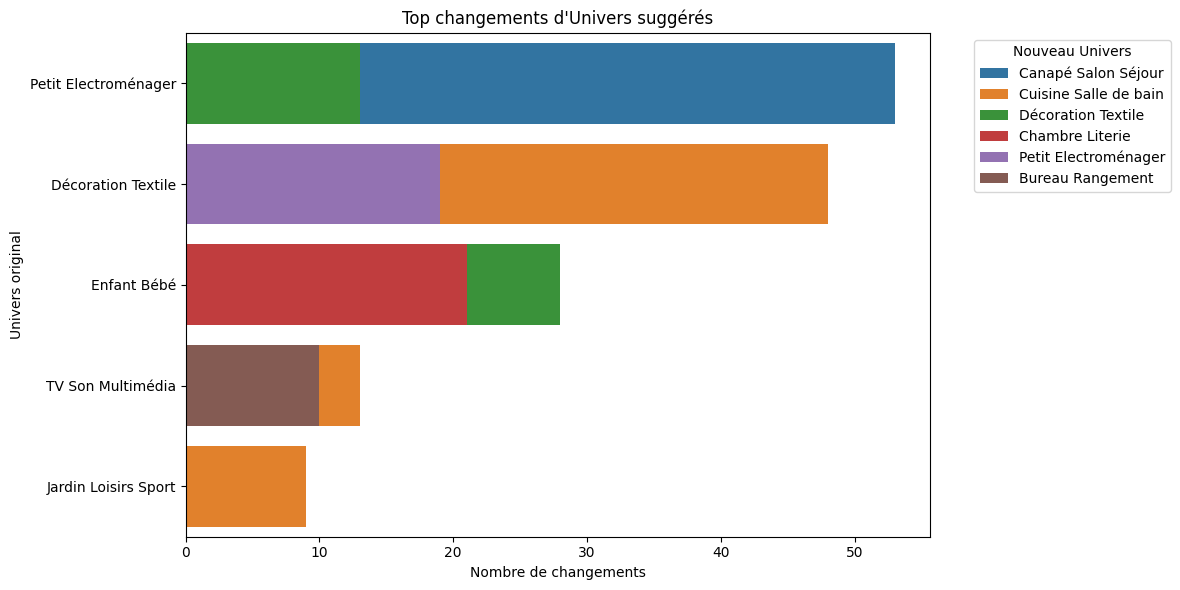

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# S'assurer que les colonnes existent
if "Univers" not in df.columns or "Univers suggéré" not in df.columns:
    raise ValueError("Les colonnes 'Univers' et 'Univers suggéré' sont nécessaires dans le DataFrame.")

# Détecter les lignes modifiées
df["univers_changed"] = df["Univers"] != df["Univers suggéré"]

# Compter les transitions (ancien → nouveau)
transitions = (
    df[df["univers_changed"]]
    .groupby(["Univers", "Univers suggéré"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

# Sélectionner les N changements les plus fréquents
top_n = 10
top_transitions = transitions.head(top_n)

# Tracer le barplot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_transitions,
    x="count",
    y="Univers",
    hue="Univers suggéré",
    dodge=False
)
plt.title("Top changements d'Univers suggérés")
plt.xlabel("Nombre de changements")
plt.ylabel("Univers original")
plt.legend(title="Nouveau Univers", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


➕ Tester différents quantiles : 0.10, 0.15, etc.

➕ Ajuster confidence_margin (actuellement à 0.10) pour rendre la correction plus ou moins agressive.